# Transmissibility-Based Multi-Component Stress Expansion

Full-field stress PSD under base excitation via:
1. **Stage 1**: Extract stress mode shapes from SEMM FRFs (all 4 components) using modal identification
2. **Stage 2**: Compute stress transmissibility $T(f,x) = G_{\sigma a}/G_{aa}$ from camera + accelerometer
3. **Decompose**: Project transmissibility onto mode shape basis $\rightarrow$ modal participation $\gamma_r(f)$
4. **Expand**: Reconstruct transmissibility for all stress components $T_c = \sum_r \gamma_r \hat\psi_{r,c}$
5. **PSD**: $S_{\sigma\sigma,c}(f,x) = |T_c(f,x)|^2 \cdot S_{aa}(f)$

---

### Key properties of this method (for the article)

**Requires accelerometer** as a reference signal for the H1 estimator.

**Noise removal (critical insight):**
The H1 estimator $T = G_{\sigma a}/G_{aa}$ uses the *cross-spectrum* between
camera (output) and accelerometer (input). Camera noise is uncorrelated with the
accelerometer, so it cancels out in the cross-spectral averaging. This means
$|T_{H1}|^2 \cdot S_{aa}$ gives the **noise-free structural stress PSD**, which
is *lower* than the raw camera Welch PSD $G_{yy}$ by a factor of $\gamma^2$ (coherence).
This is a feature, not a bug — see the validation section for a detailed breakdown.

**Separates structure from excitation:**
The transmissibility $T(f,x)$ is a structural property independent of the
excitation spectrum. Once computed, it can predict stress PSD under any
acceleration input $S_{aa}(f)$ without re-measurement.

**Comparison with direct PSD expansion:**
The direct PSD method (see companion notebook) works on $G_{yy}$ directly and
therefore reproduces the *denoised* camera PSD. Both methods achieve noise removal
(this one via cross-spectral H1, the other via virtual-reference denoising).
The transmissibility method's advantage is that $T(f,x)$ is a reusable structural
property separating the transfer function from the excitation.

In [57]:
import sys
import json
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from scipy.signal import welch, get_window, resample, find_peaks

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == 'dual_stage_base_pipeline' else cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from dual_stage_base_pipeline.semm_thermoelastic_pipeline import SEMMThermoelasticPipeline

# Optional: sdypy for advanced modal identification
try:
    import sdypy as sp
    HAS_SDYPY = True
    print(f'sdypy {sp.__version__} available')
except ImportError:
    HAS_SDYPY = False
    print('sdypy not available; using peak-based mode shape extraction')

print(f'PROJECT_ROOT = {PROJECT_ROOT}')

sdypy 0.5.1 available
PROJECT_ROOT = <repo>


In [58]:
import os

# ==============================================================================
#  CONFIGURATION
# ==============================================================================

# DATA_ROOT points to where all measurement data and pipeline outputs live
# DATA_ROOT is the only path that must be adapted: point it at the directory
# holding the measurement recordings (see the README). It can also be supplied
# through the THERMO_DATA_ROOT environment variable.
DATA_ROOT = Path(os.environ.get('THERMO_DATA_ROOT', r'C:\path\to\dataset')).resolve()
PIPE_DIR = PROJECT_ROOT / 'dual_stage_base_pipeline'

# --- Stage 1 pre-computed outputs ---
STAGE1_RUN = 'stage1_20260306_075427'
STAGE1_DIR = DATA_ROOT / STAGE1_RUN

Y_SEMM_PATH      = STAGE1_DIR / 'stage1' / 'Y_SEMM_stage1.npy'
FREQ_AXIS_PATH   = STAGE1_DIR / 'stage1' / 'freq_axis.npy'
MAPPING_META_PATH = STAGE1_DIR / 'stage1' / 'mapping_metadata.json'
RUN_META_PATH    = STAGE1_DIR / 'run_metadata.json'
NODE_COORDS_PATH = STAGE1_DIR / 'stage1' / 'node_coords.npy'

# --- Stage 2 base excitation data ---
MEAS_DIR = DATA_ROOT / 'experiment_20260305' / 'stage2_shaker'
CAMERA_HCC_PATH = (DATA_ROOT / 'experiment_20260305' / 'stage2_camera'
                   / 'DefaultName_20260305T073259507'
                   / '_20260305T073259507_20260305T073259947.hcc')
ACCEL_PKL_PATH  = MEAS_DIR / '20260305_073124_base_excitation.pkl'
ACCEL_TASK      = 'AccelerationTask'
ACCEL_CHANNEL   = 'Acceleration'
ACCEL_IN_G      = True
G0              = 9.80665

# --- Time alignment (from cross-correlation) ---
# Camera recording starts 49 frames (24.5 ms) before accelerometer recording.
# Trim these leading camera frames so both signals start at the same instant.
CAM_LEAD_FRAMES = 49          # camera frames to discard at the start

# --- Processing ---
CROP_JSON = PIPE_DIR / 'configs' / 'crop.json'
with open(CROP_JSON) as f:
    CROP = json.load(f)
print(f'Crop: {CROP}')

REDUCE_FACTOR = 3
FLIP_VERTICAL = False
N_SEGMENTS    = 5
F_MIN, F_MAX  = 50.0, 300.0
FS_IR         = 2000.0   # camera frame rate [Hz]

# --- Component labels ---
COMPS = {0: 'SX', 1: 'SY', 2: 'SXY', 3: 'SX+SY'}
CAM_COMP = 3                  # camera measures SX+SY

# --- Mode shape extraction ---
USE_SDYPY_EMA    = True       # True: sdypy-EMA automatic pole refinement;  False: peak-based
POL_ORDER_HIGH   = 40         # max polynomial order for sdypy-EMA
EMA_F_WINDOW     = 20.0       # search window ±Hz around each peak
EMA_ERR_FN       = 0.05       # max rel. freq. deviation for accepted poles
EMA_ERR_XI       = 0.05       # max damping for accepted poles
PEAK_DISTANCE_HZ = 15.0
PEAK_HEIGHT_REL  = 0.02
PEAK_PROM_REL    = 0.02
N_MODES_MAX      = 2          # keep only the N strongest modes

print(f'Stage 1 run:    {STAGE1_RUN}')
print(f'Stage 2 camera: {CAMERA_HCC_PATH.name}')
print(f'Stage 2 accel:  {ACCEL_PKL_PATH.name}')
print(f'Freq band:      {F_MIN}–{F_MAX} Hz')

Crop: {'row_start': 17, 'row_end': 121, 'col_start': 14, 'col_end': 118}
Stage 1 run:    stage1_20260306_075427
Stage 2 camera: _20260305T073259507_20260305T073259947.hcc
Stage 2 accel:  20260305_073124_base_excitation.pkl
Freq band:      50.0–300.0 Hz


In [59]:
# ==============================================================================
#  HELPER FUNCTIONS
# ==============================================================================

def compute_h1_frf(ref, response_2d, fs, seg_len, window='hann'):
    """
    Vectorised H1 FRF estimator with coherence.

    Parameters
    ----------
    ref : (N,) reference signal  (accelerometer)
    response_2d : (N, C) response signals  (camera pixels as stress)
    fs : sampling frequency [Hz]
    seg_len : Welch segment length [samples]

    Returns
    -------
    freq : (F,)   frequency vector [Hz]
    H1   : (F, C) complex H1 FRF
    coh  : (F, C) ordinary coherence  gamma^2
    Gxx  : (F,)   reference auto-PSD
    """
    n = len(ref)
    hop = seg_len // 2
    win = get_window(window, seg_len)
    wss = np.sum(win ** 2)
    freq = np.fft.rfftfreq(seg_len, 1.0 / fs)
    nf, nch = len(freq), response_2d.shape[1]

    Gxx = np.zeros(nf)
    Gyx = np.zeros((nf, nch), dtype=complex)
    Gyy = np.zeros((nf, nch))
    n_avg = 0

    for s in range(0, n - seg_len + 1, hop):
        xw = ref[s:s + seg_len] * win
        yw = response_2d[s:s + seg_len] * win[:, None]
        X = np.fft.rfft(xw)
        Y = np.fft.rfft(yw, axis=0)
        Gxx += (X.conj() * X).real / wss
        Gyx += Y * X.conj()[:, None] / wss
        Gyy += (Y.conj() * Y).real / wss
        n_avg += 1

    Gxx /= n_avg
    Gyx /= n_avg
    Gyy /= n_avg

    H1  = Gyx / (Gxx[:, None] + 1e-30)
    coh = np.abs(Gyx) ** 2 / (Gyy * Gxx[:, None] + 1e-30)

    return freq, H1, coh, Gxx


def camera_to_nodes(cam_flat, cam_to_node, n_nodes):
    """Average camera-pixel values onto the FE node grid."""
    vals  = np.zeros(n_nodes)
    count = np.zeros(n_nodes)
    for ip, inod in enumerate(cam_to_node):
        vals[inod]  += cam_flat[ip]
        count[inod] += 1
    count[count == 0] = 1
    return vals / count


def camera_to_nodes_complex(cam_flat, cam_to_node, n_nodes):
    """Average complex camera-pixel values onto FE nodes."""
    vals  = np.zeros(n_nodes, dtype=complex)
    count = np.zeros(n_nodes)
    for ip, inod in enumerate(cam_to_node):
        vals[inod]  += cam_flat[ip]
        count[inod] += 1
    count[count == 0] = 1
    return vals / count


def safe_clim(values, pct=1):
    """Robust symmetric colour limits from percentiles."""
    v = np.abs(values[np.isfinite(values)])
    if len(v) == 0:
        return -1, 1
    lo, hi = np.percentile(v, [pct, 100 - pct])
    mx = max(abs(hi), 1e-30)
    return 0, mx


print('Helpers defined.')

Helpers defined.


---
## 1 &mdash; Load Stage 1 Data

In [60]:
Y_SEMM     = np.load(Y_SEMM_PATH)           # (n_freq, n_nodes*4, n_cases) complex
freq_axis  = np.load(FREQ_AXIS_PATH)         # (n_freq,)
node_coords = np.load(NODE_COORDS_PATH)      # (n_nodes, 3)

with open(MAPPING_META_PATH) as f:
    mapping_meta = json.load(f)

n_freq_s1  = len(freq_axis)
n_nodes    = node_coords.shape[0]
n_cases    = Y_SEMM.shape[2]
rows_grid  = mapping_meta['rows']
cols_grid  = mapping_meta['cols']
df_s1      = float(np.median(np.diff(freq_axis)))

assert Y_SEMM.shape[1] == n_nodes * 4, 'Interleaved layout mismatch'

# Triangulation for all spatial plots
tri = mtri.Triangulation(node_coords[:, 0], node_coords[:, 1])

print(f'Y_SEMM        : {Y_SEMM.shape}  ({n_nodes} nodes x 4 components x {n_cases} cases)')
print(f'freq_axis     : {freq_axis[0]:.1f} .. {freq_axis[-1]:.1f} Hz,  df = {df_s1:.3f} Hz')
print(f'Grid          : {rows_grid} x {cols_grid} = {n_nodes} nodes')

Y_SEMM        : (1229, 4624, 6)  (1156 nodes x 4 components x 6 cases)
freq_axis     : 50.0 .. 299.9 Hz,  df = 0.203 Hz
Grid          : 34 x 34 = 1156 nodes


---
## 2 &mdash; Extract Stress Mode Shapes from Stage 1 FRFs

Identify resonance frequencies from the spatial-RMS of the SEMM FRF, then
extract mode shapes for **all four stress components** at each resonance.
All shapes are normalised by the camera-component (SX+SY) norm so that
inter-component ratios are preserved.

In [61]:

# ---- Spatial-RMS of the camera component (SX+SY) across cases ----
H_cam = Y_SEMM[:, CAM_COMP::4, :]                       # (n_freq, n_nodes, n_cases)
rms_spatial = np.sqrt(np.mean(np.abs(H_cam) ** 2, axis=(1, 2)))  # (n_freq,)

# ---- Find peaks (always runs — used as seeds for EMA or directly) ----
min_dist_bins = max(1, int(PEAK_DISTANCE_HZ / df_s1))
peaks, props = find_peaks(
    rms_spatial,
    distance=min_dist_bins,
    height=PEAK_HEIGHT_REL * np.max(rms_spatial),
    prominence=PEAK_PROM_REL * np.max(rms_spatial),
)
peaks = peaks[np.argsort(-rms_spatial[peaks])]  # sort strongest first
peaks = peaks[:N_MODES_MAX]
f_peaks = freq_axis[peaks]
print(f'Peak-picker seeds: {np.round(f_peaks, 1)} Hz')

if USE_SDYPY_EMA and HAS_SDYPY:
    print('\n>>> Running sdypy-EMA on SX+SY component ...')
    H_cam_2d = H_cam.mean(axis=1).T                  # (n_cases, n_freq)
    model = sp.EMA.Model(
        frf=H_cam_2d,
        freq=freq_axis,
        pol_order_high=POL_ORDER_HIGH,
        lower=F_MIN,
        upper=F_MAX,
    )
    model.get_poles(method='lscf', show_progress=True)
    model.select_closest_poles(
        approx_nat_freq=list(f_peaks),
        f_window=EMA_F_WINDOW,
        fn_temp=0.01,
        xi_temp=0.10,
    )
    refined = model.nat_freq
    if np.any(refined <= 0):
        print(f'WARNING: EMA returned invalid poles {refined} — falling back to peak-picker')
    else:
        print(f'Refined poles: {np.round(refined, 2)} Hz')
        f_peaks = refined
        peaks = np.array([np.argmin(np.abs(freq_axis - fp)) for fp in f_peaks])

# ---- Extract mode shapes at each peak for all components (SVD) ----
# U[:, 0] from SVD has unit norm; S[0] carries the physical amplitude.
# Including S[0] preserves inter-component amplitude ratios (SX vs SY vs SXY).
n_modes = len(peaks)
mode_shapes = {}   # mode_shapes[comp_label] -> (n_nodes, n_modes)

for comp_idx, comp_label in COMPS.items():
    shapes = np.zeros((n_nodes, n_modes))
    for m, k in enumerate(peaks):
        H_k = Y_SEMM[k, comp_idx::4, :]   # (n_nodes, n_cases)
        U, S, Vh = np.linalg.svd(H_k, full_matrices=False)
        shapes[:, m] = U[:, 0].real * S[0]  # scale by singular value
    mode_shapes[comp_label] = shapes

Psi_cam      = mode_shapes['SX+SY']                # (n_nodes, n_modes)
Psi_cam_pinv = np.linalg.pinv(Psi_cam)             # (n_modes, n_nodes)

print(f'\nMode shapes extracted: {n_modes} modes')
for m in range(n_modes):
    norms = {cl: np.linalg.norm(mode_shapes[cl][:, m]) for cl in COMPS.values()}
    print(f'  Mode {m+1}: f = {f_peaks[m]:.1f} Hz')
    for cl, nm in norms.items():
        print(f'    ||psi_{cl}|| = {nm:.4e}')
    print(f'    SXY/SX+SY ratio = {norms["SXY"]/norms["SX+SY"]:.3f}')

Peak-picker seeds: [ 54.3 173.7] Hz

>>> Running sdypy-EMA on SX+SY component ...


100%|██████████████████████████████████████████████████████████████| 40/40 [00:00<00:00, 523.49it/s]

Refined poles: [ 54.34 173.83] Hz

Mode shapes extracted: 2 modes
  Mode 1: f = 54.3 Hz
    ||psi_SX|| = 1.6908e+07
    ||psi_SY|| = 5.6001e+07
    ||psi_SXY|| = 6.5584e+06
    ||psi_SX+SY|| = 7.1864e+07
    SXY/SX+SY ratio = 0.091
  Mode 2: f = 173.8 Hz
    ||psi_SX|| = 5.1525e+07
    ||psi_SY|| = 9.0703e+07
    ||psi_SXY|| = 7.2871e+07
    ||psi_SX+SY|| = 1.1777e+08
    SXY/SX+SY ratio = 0.619


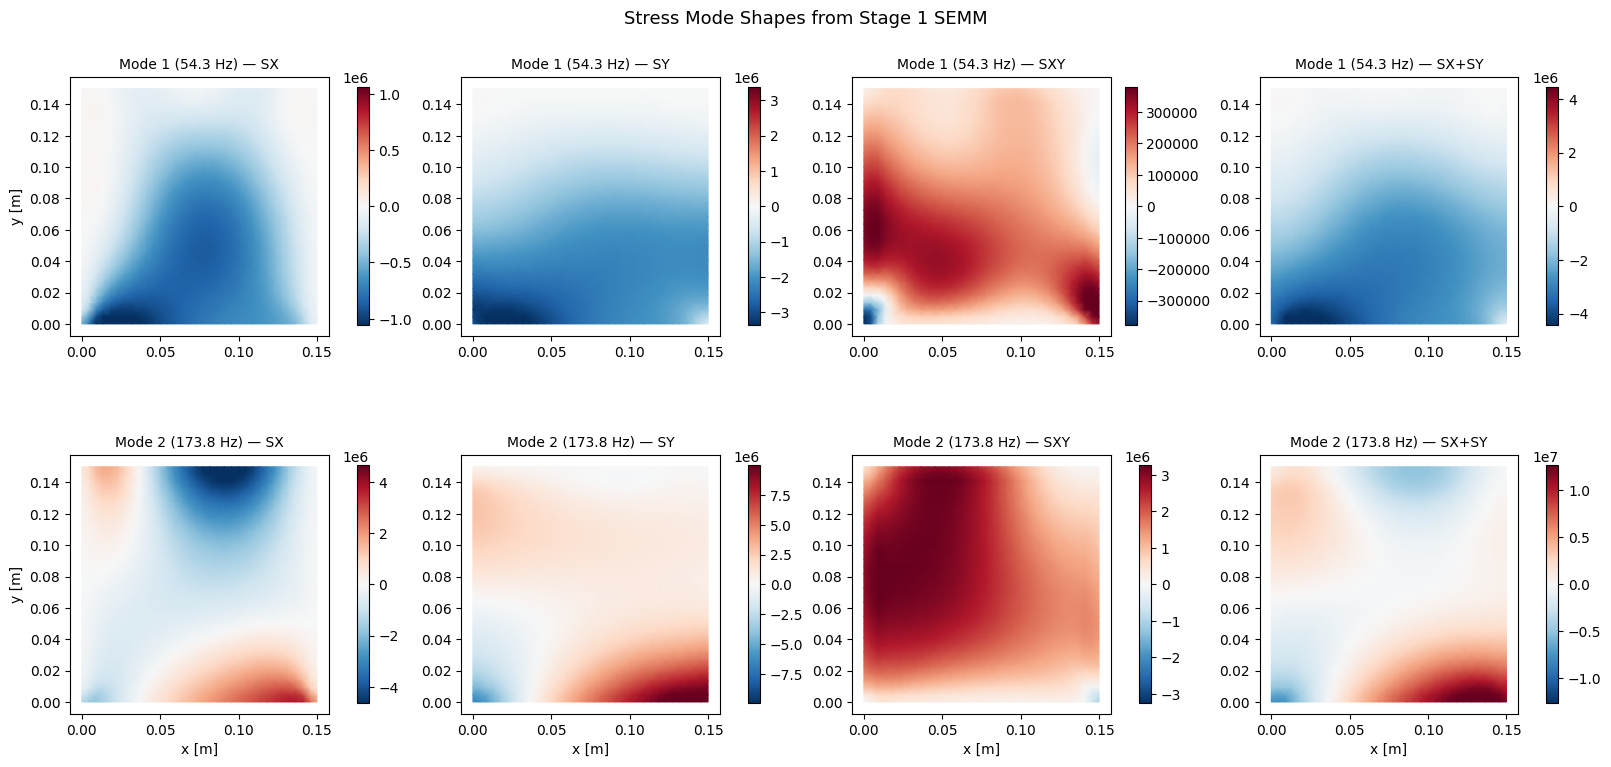

In [62]:
# ---- Visualise mode shapes (all components) ----
fig, axes = plt.subplots(n_modes, 4, figsize=(16, 3.8 * n_modes),
                         constrained_layout=True)
if n_modes == 1:
    axes = axes[None, :]

for m in range(n_modes):
    for j, (ci, cl) in enumerate(COMPS.items()):
        ax = axes[m, j]
        vals = mode_shapes[cl][:, m]
        vlim = np.percentile(np.abs(vals[np.isfinite(vals)]), 99)
        vlim = max(vlim, 1e-30)
        tc = ax.tripcolor(tri, vals, shading='gouraud', cmap='RdBu_r',
                          vmin=-vlim, vmax=vlim)
        plt.colorbar(tc, ax=ax, fraction=0.046, pad=0.04)
        ax.set_aspect('equal')
        ax.set_title(f'Mode {m+1} ({f_peaks[m]:.1f} Hz) — {cl}', fontsize=10)
        if j == 0:
            ax.set_ylabel('y [m]')
        if m == n_modes - 1:
            ax.set_xlabel('x [m]')

fig.suptitle('Stress Mode Shapes from Stage 1 SEMM', fontsize=13, y=1.01)
plt.show()

---
## 3 &mdash; Load & Preprocess Stage 2 Data (Camera + Accelerometer)

In [63]:
# ---- Interactive crop selection (OPTIONAL) ----
# Run this cell to pick a new crop. Click TWO corners on the image, then close.
# CROP will be updated for all downstream cells.
# SKIP this cell to keep the default CROP from config.

# %matplotlib qt
# from fasthcc import read_hcc as _read_hcc
# _raw = np.asarray(_read_hcc(str(CAMERA_HCC_PATH), calibrated=True)[0], dtype=np.float64)
# if FLIP_VERTICAL:
#     _raw = _raw[:, ::-1, :]

# fig, ax = plt.subplots(figsize=(8, 6))
# ax.imshow(_raw[0], cmap='inferno', aspect='auto')
# ax.set_title('Click TOP-LEFT then BOTTOM-RIGHT corner of ROI (2 clicks)')
# ax.set_xlabel('col')
# ax.set_ylabel('row')

# # Draw current crop rectangle
# from matplotlib.patches import Rectangle
# r = Rectangle((CROP['col_start'], CROP['row_start']),
#               CROP['col_end'] - CROP['col_start'],
#               CROP['row_end'] - CROP['row_start'],
#               linewidth=2, edgecolor='cyan', facecolor='none', linestyle='--', label='current CROP')
# ax.add_patch(r)
# ax.legend(loc='upper right')
# plt.tight_layout()

# pts = plt.ginput(2, timeout=0)
# plt.close()

# if len(pts) == 2:
#     c1, r1 = pts[0]
#     c2, r2 = pts[1]
#     CROP = {
#         'row_start': int(min(r1, r2)),
#         'row_end':   int(max(r1, r2)),
#         'col_start': int(min(c1, c2)),
#         'col_end':   int(max(c1, c2)),
#     }
#     print(f'NEW CROP = {CROP}')
#     _cropped = SEMMThermoelasticPipeline.crop_video(_raw, CROP)
#     _reduced = SEMMThermoelasticPipeline.reduce_resolution(_cropped, REDUCE_FACTOR, mode='crop')
#     print(f'After crop: {_cropped.shape},  after reduce: {_reduced.shape}')
# else:
#     print(f'No clicks registered, keeping CROP = {CROP}')

# del _raw
# %matplotlib inline

In [64]:
# ---- Camera (HCC via fasthcc) ----
from fasthcc import read_hcc

images_raw, _meta = read_hcc(str(CAMERA_HCC_PATH), calibrated=True, metadata=True)
images_raw = np.asarray(images_raw, dtype=np.float64)
print(f'Camera raw       : {images_raw.shape}')

# Time-align: trim leading camera frames that precede the accelerometer recording
if CAM_LEAD_FRAMES > 0:
    images_raw = images_raw[CAM_LEAD_FRAMES:]
    print(f'After alignment  : {images_raw.shape}  (trimmed {CAM_LEAD_FRAMES} leading frames)')

if FLIP_VERTICAL:
    images_raw = images_raw[:, ::-1, :]

images_crop = SEMMThermoelasticPipeline.crop_video(images_raw, CROP)
images_red  = SEMMThermoelasticPipeline.reduce_resolution(images_crop, REDUCE_FACTOR, mode='crop')

n_frames, rows_cam, cols_cam = images_red.shape
n_pixels = rows_cam * cols_cam
print(f'After crop+reduce: {images_red.shape}  ({n_pixels} pixels)')

# Remove DC  &  convert to stress
images_ac = images_red - images_red.mean(axis=0, keepdims=True)
factor_pa_per_k = SEMMThermoelasticPipeline._camera_to_stress_factor_pa_per_k()
sigma_cam_3d = images_ac * factor_pa_per_k          # (n_frames, rows, cols)  Pa
sigma_cam_2d = sigma_cam_3d.reshape(n_frames, -1)   # (n_frames, n_pixels)
cam_spatial_avg = sigma_cam_2d.mean(axis=1)          # (n_frames,)

print(f'Stress factor    : {factor_pa_per_k:.2f} Pa/K')
print(f'sigma_cam_2d     : {sigma_cam_2d.shape}')

# ---- Accelerometer ----
with open(ACCEL_PKL_PATH, 'rb') as f:
    pkl = pickle.load(f)
task = pkl[ACCEL_TASK]
accel_data = np.asarray(task['data'], dtype=float)
fs_acc = float(task['sample_rate'])
ch_names = list(task.get('channel_names', []))
i_ch = ch_names.index(ACCEL_CHANNEL)
accel_raw = accel_data[:, i_ch] - np.mean(accel_data[:, i_ch])
if ACCEL_IN_G:
    accel_raw = accel_raw * G0

print(f'\nAccelerometer    : {len(accel_raw)} samples @ {fs_acc:.0f} Hz')
print(f'Duration (accel) : {len(accel_raw)/fs_acc:.3f} s')

cam_duration = n_frames / FS_IR
print(f'Duration (camera): {cam_duration:.3f} s')

# ---- Take matching time window from accelerometer, then resample ----
n_accel_keep = int(round(cam_duration * fs_acc))
n_accel_keep = min(n_accel_keep, len(accel_raw))
accel_window = accel_raw[:n_accel_keep]
accel = resample(accel_window, n_frames)
print(f'Accel window     : {n_accel_keep} samples ({n_accel_keep/fs_acc:.3f} s) -> resampled to {n_frames}')

# ---- Welch parameters ----
seg_len = int(2 * n_frames / (N_SEGMENTS + 1))
print(f'\nWelch segment    : {seg_len} samples ({seg_len/FS_IR*1e3:.1f} ms)')
print(f'Freq resolution  : {FS_IR/seg_len:.3f} Hz')

# ---- Camera pixel -> FE node mapping ----
x_range = mapping_meta['diag_cam']['x_range']
y_range = mapping_meta['diag_cam']['y_range']
xs = np.linspace(x_range[0], x_range[1], cols_cam)
ys = np.linspace(y_range[1], y_range[0], rows_cam)
xx, yy = np.meshgrid(xs, ys)
cam_positions = np.column_stack([xx.ravel(), yy.ravel()])

d2 = np.sum((cam_positions[:, None, :] - node_coords[None, :, :2]) ** 2, axis=2)
cam_to_node = np.argmin(d2, axis=1)
print(f'Pixel-to-node map: {n_pixels} pixels -> {len(np.unique(cam_to_node))} unique nodes')

Camera raw       : (12000, 132, 128)
After alignment  : (11951, 132, 128)  (trimmed 49 leading frames)
After crop+reduce: (11951, 34, 34)  (1156 pixels)
Stress factor    : -360403117.56 Pa/K
sigma_cam_2d     : (11951, 1156)

Accelerometer    : 256000 samples @ 25600 Hz
Duration (accel) : 10.000 s
Duration (camera): 5.976 s
Accel window     : 152973 samples (5.976 s) -> resampled to 11951

Welch segment    : 3983 samples (1991.5 ms)
Freq resolution  : 0.502 Hz
Pixel-to-node map: 1156 pixels -> 1156 unique nodes


### 3b. Coherence diagnostic (removed)

*Virtual-reference coherence diagnostic removed — camera and accelerometer are now synchronised.*

In [65]:
# [REMOVED] Virtual-reference coherence diagnostic — no longer needed.
# Camera and accelerometer are now synchronised (same trigger).
# Cam-vs-accel coherence is computed in the proper H1 cell below.
pass

## 4. Stress Transmissibility — H1 estimator

$$T(f,x) = \frac{G_{\sigma a}(f,x)}{G_{aa}(f)}$$

Proper H1 estimator using synchronised camera and accelerometer data.

In [66]:
# ---- Proper H1 transmissibility: T(f) = G_σa / G_aa ----
# Camera and accelerometer are synchronised (same LDAQ trigger).

freq_h1, T_cam_pix, coh_pix, Gaa_full = compute_h1_frf(
    accel, sigma_cam_2d, FS_IR, seg_len)

print(f'H1 transmissibility:')
print(f'  T_cam_pix : {T_cam_pix.shape}  (complex, Pa/(m/s²))')
print(f'  coh_pix   : {coh_pix.shape}')
print(f'  freq_h1   : {freq_h1[0]:.2f} .. {freq_h1[-1]:.2f} Hz')

# ---- Band-limit ----
band = (freq_h1 >= F_MIN) & (freq_h1 <= F_MAX)
freq_b   = freq_h1[band]
T_cam_b  = T_cam_pix[band]     # (n_freq_b, n_pixels)
coh_b    = coh_pix[band]
Gaa_b    = Gaa_full[band]
print(f'\nBand-limited     : {len(freq_b)} lines,  {freq_b[0]:.1f} .. {freq_b[-1]:.1f} Hz')

# ---- Map transmissibility from pixels to FE nodes ----
n_freq_b = len(freq_b)
T_cam_nodes = np.zeros((n_freq_b, n_nodes), dtype=complex)
coh_nodes   = np.zeros((n_freq_b, n_nodes))

for k in range(n_freq_b):
    T_cam_nodes[k] = camera_to_nodes_complex(T_cam_b[k], cam_to_node, n_nodes)
    coh_nodes[k]   = camera_to_nodes(coh_b[k], cam_to_node, n_nodes)

print(f'T_cam_nodes  : {T_cam_nodes.shape}')
print(f'coh_nodes    : {coh_nodes.shape}')

# ---- Detect Stage 2 resonance peaks (local max near each Stage 1 mode) ----
T_rms_full = np.sqrt(np.mean(np.abs(T_cam_nodes) ** 2, axis=1))
f_peaks_s1 = f_peaks.copy()

f_res_s2 = np.zeros(n_modes)
for m in range(n_modes):
    mask = np.abs(freq_b - f_peaks_s1[m]) <= PEAK_DISTANCE_HZ
    if np.any(mask):
        f_res_s2[m] = freq_b[mask][np.argmax(T_rms_full[mask])]
    else:
        f_res_s2[m] = f_peaks_s1[m]

f_peaks = f_res_s2
print(f'\nStage 2 resonances: {np.round(f_peaks, 1)} Hz  (Stage 1 seeds: {np.round(f_peaks_s1, 1)} Hz)')

H1 transmissibility:
  T_cam_pix : (1992, 1156)  (complex, Pa/(m/s²))
  coh_pix   : (1992, 1156)
  freq_h1   : 0.00 .. 999.75 Hz

Band-limited     : 498 lines,  50.2 .. 299.8 Hz
T_cam_nodes  : (498, 1156)
coh_nodes    : (498, 1156)

Stage 2 resonances: [ 53.7 174.7] Hz  (Stage 1 seeds: [ 54.3 173.8] Hz)


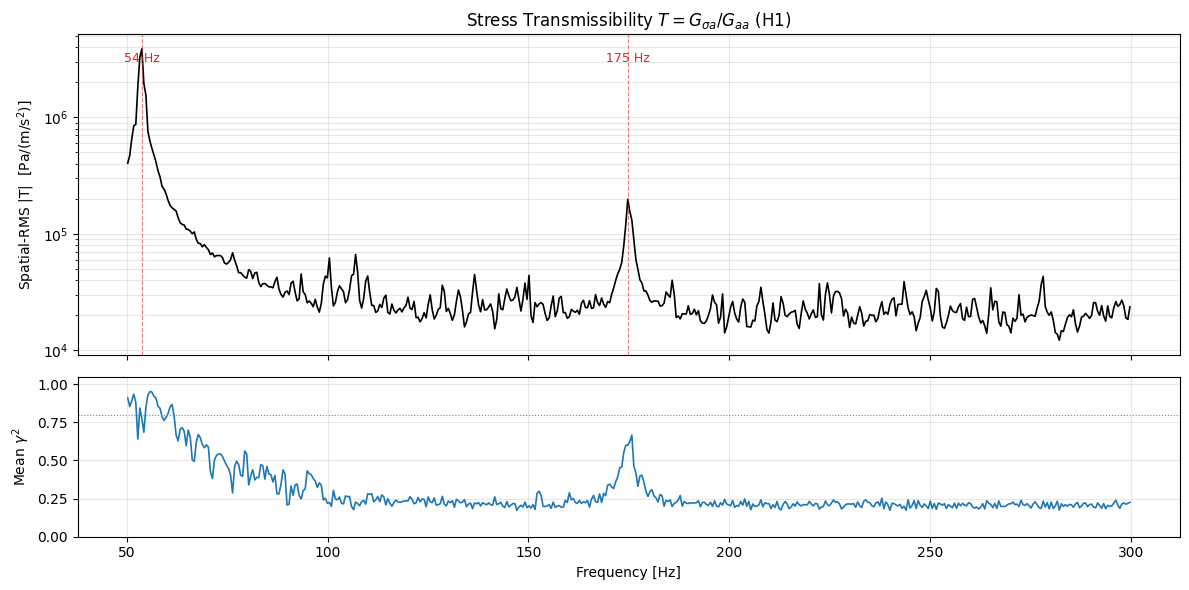

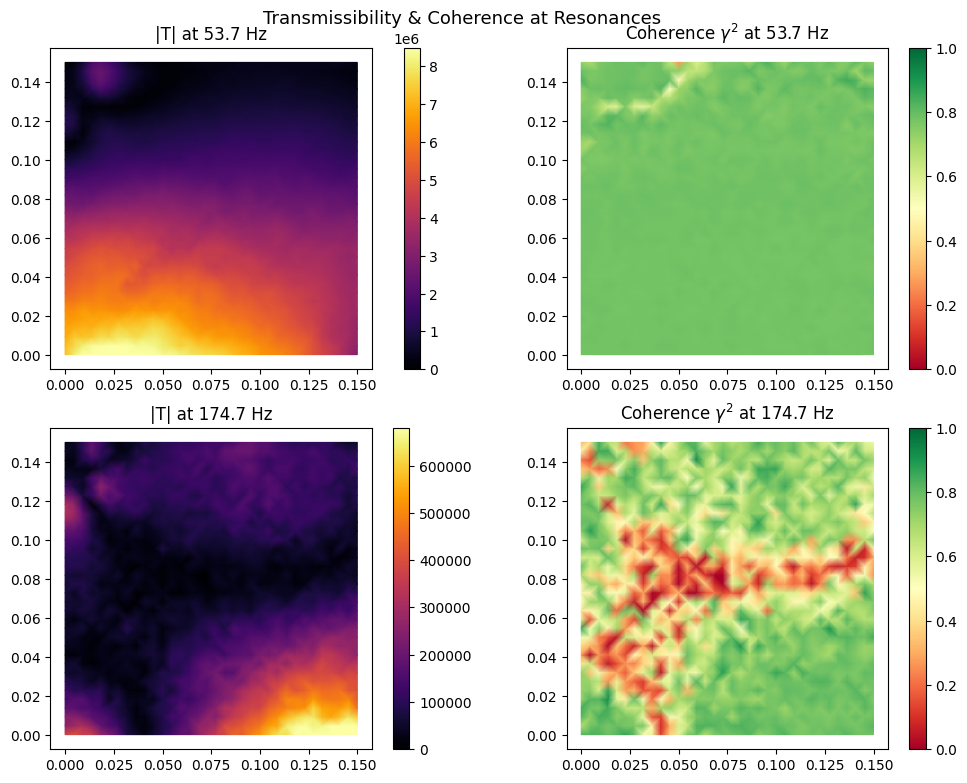

In [67]:
# ---- Transmissibility magnitude & coherence overview ----
T_rms = np.sqrt(np.mean(np.abs(T_cam_nodes) ** 2, axis=1))  # spatial RMS
coh_mean = np.mean(coh_nodes, axis=1)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True,
                                gridspec_kw={'height_ratios': [2, 1]})

ax1.semilogy(freq_b, T_rms, 'k', lw=1.2)
for m, fp in enumerate(f_peaks):
    ax1.axvline(fp, color='C3', ls='--', lw=0.8, alpha=0.6)
    ax1.text(fp, ax1.get_ylim()[1] * 0.7, f'{fp:.0f} Hz',
             ha='center', va='top', fontsize=9, color='C3')
ax1.set_ylabel('Spatial-RMS |T|  [Pa/(m/s$^2$)]')
ax1.set_title('Stress Transmissibility $T = G_{\\sigma a} / G_{aa}$ (H1)')
ax1.grid(True, alpha=0.3, which='both')

ax2.plot(freq_b, coh_mean, 'C0', lw=1.2)
ax2.axhline(0.8, color='grey', ls=':', lw=0.8)
ax2.set_ylabel('Mean $\\gamma^2$')
ax2.set_xlabel('Frequency [Hz]')
ax2.set_ylim(0, 1.05)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ---- Spatial maps at resonances ----
fig, axes = plt.subplots(n_modes, 2, figsize=(10, 3.8 * n_modes),
                         constrained_layout=True)
if n_modes == 1:
    axes = axes[None, :]

for m in range(n_modes):
    k_res = np.argmin(np.abs(freq_b - f_peaks[m]))

    ax = axes[m, 0]
    vals = np.abs(T_cam_nodes[k_res])
    vmin, vmax = safe_clim(vals)
    tc = ax.tripcolor(tri, vals, shading='gouraud', cmap='inferno',
                      vmin=vmin, vmax=vmax)
    plt.colorbar(tc, ax=ax, fraction=0.046, pad=0.04)
    ax.set_aspect('equal')
    ax.set_title(f'|T| at {freq_b[k_res]:.1f} Hz')

    ax = axes[m, 1]
    vals = coh_nodes[k_res]
    tc = ax.tripcolor(tri, vals, shading='gouraud', cmap='RdYlGn',
                      vmin=0, vmax=1)
    plt.colorbar(tc, ax=ax, fraction=0.046, pad=0.04)
    ax.set_aspect('equal')
    ax.set_title(f'Coherence $\\gamma^2$ at {freq_b[k_res]:.1f} Hz')

fig.suptitle('Transmissibility & Coherence at Resonances', fontsize=13, y=1.01)
plt.show()

---
## 5 &mdash; Modal Decomposition of Transmissibility

Project the measured node-grid transmissibility onto the mode shape basis
at every frequency:
$$\gamma_r(f) = \hat\Psi_\text{cam}^+ \, T_\text{cam}(f)$$

This gives the complex modal participation function $\gamma_r(f)$, which peaks
at the resonance of mode $r$.

### What the decomposition achieves

- The pseudo-inverse projects the 841-node transmissibility field onto 2 mode shapes
- At resonance, the transmissibility is dominated by one mode, so the projection captures nearly all the signal
- Away from resonance, the 2-mode basis cannot represent the full field (noise, other modes) &mdash; the residual is high there, but that's fine because there's little structural energy to capture
- The reconstruction $T_\text{recon} = \sum_r \gamma_r \hat\psi_r$ preserves the spatial pattern and amplitude of the H1 transmissibility (not the raw camera Gyy)

### Why spatial plots match but frequency plots differ

- **Spatial comparison** (section 5 plots): compares $|T_{H1}|$ vs $|T_{recon}|$ &mdash; both derived from H1, so they match in shape AND amplitude
- **Frequency comparison** (section 7): compares $|T_{recon}|^2 \cdot S_{aa}$ vs direct Welch $G_{yy}$ &mdash; these differ by the coherence factor $\gamma^2$ because H1 removes noise while Welch includes it

In [68]:
# ---- Modal decomposition ----
gamma = (Psi_cam_pinv @ T_cam_nodes.T).T   # (n_freq_b, n_modes)  complex

# ---- Reconstruction & accuracy ----
T_recon = gamma @ Psi_cam.T                 # (n_freq_b, n_nodes)  complex

residual_norm = np.linalg.norm(T_cam_nodes - T_recon, axis=1)
signal_norm   = np.linalg.norm(T_cam_nodes, axis=1) + 1e-30
relative_residual = residual_norm / signal_norm
accuracy = (1 - relative_residual) * 100   # %  (100% = perfect)

print(f'gamma shape     : {gamma.shape}')
print(f'T_recon shape   : {T_recon.shape}')

# ---- Print per-mode reconstruction accuracy at resonances ----
print(f'\nReconstruction accuracy at resonances:')
for m in range(n_modes):
    k_res = np.argmin(np.abs(freq_b - f_peaks[m]))
    print(f'  Mode {m+1} ({f_peaks[m]:.1f} Hz):  accuracy = {accuracy[k_res]:.1f}%,  '
          f'|gamma| = {np.abs(gamma[k_res, m]):.4e}')

gamma shape     : (498, 2)
T_recon shape   : (498, 1156)

Reconstruction accuracy at resonances:
  Mode 1 (53.7 Hz):  accuracy = 78.3%,  |gamma| = 1.7701e+00
  Mode 2 (174.7 Hz):  accuracy = 59.0%,  |gamma| = 4.8741e-02


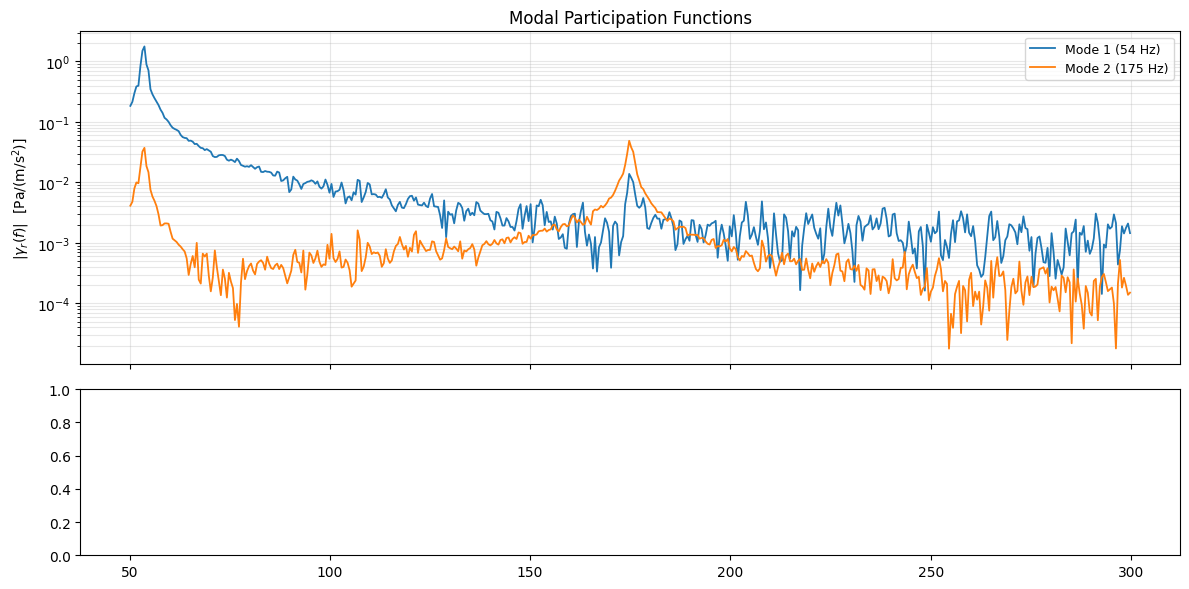

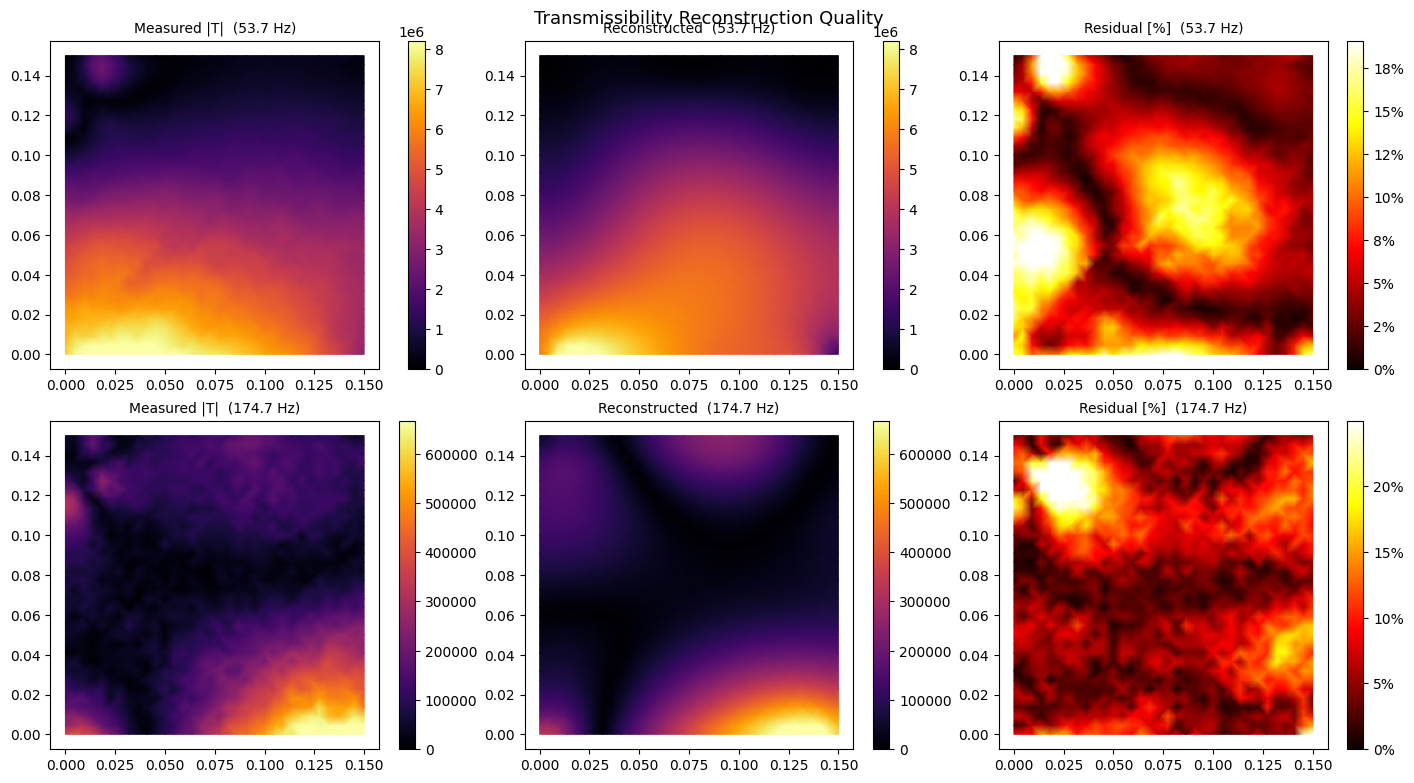

In [69]:
# ---- Modal participation spectra ----
fig, (ax1,ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True,
                                gridspec_kw={'height_ratios': [2, 1]})

for m in range(n_modes):
    ax1.semilogy(freq_b, np.abs(gamma[:, m]), lw=1.3,
                 label=f'Mode {m+1} ({f_peaks[m]:.0f} Hz)')
ax1.set_ylabel('$|\\gamma_r(f)|$  [Pa/(m/s$^2$)]')
ax1.set_title('Modal Participation Functions')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3, which='both')

# ax2.plot(freq_b, accuracy, 'k', lw=1)
# for m in range(n_modes):
#     k_res = np.argmin(np.abs(freq_b - f_peaks[m]))
#     ax2.plot(freq_b[k_res], accuracy[k_res], 'rv', ms=8)
#     ax2.annotate(f'{accuracy[k_res]:.0f}%', (freq_b[k_res], accuracy[k_res]),
#                  textcoords='offset points', xytext=(8, 5), fontsize=9, color='C3')
# ax2.set_ylabel('Reconstruction accuracy [%]')
# ax2.set_xlabel('Frequency [Hz]')
# ax2.set_ylim(None, 105)
# ax2.axhline(0, color='grey', ls=':', lw=0.5)
# ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ---- Spatial comparison: measured vs reconstructed at resonances ----
fig, axes = plt.subplots(n_modes, 3, figsize=(14, 3.8 * n_modes),
                         constrained_layout=True)
if n_modes == 1:
    axes = axes[None, :]

for m in range(n_modes):
    k_res = np.argmin(np.abs(freq_b - f_peaks[m]))
    meas  = np.abs(T_cam_nodes[k_res])
    recon = np.abs(T_recon[k_res])
    resid_pct = 100 * np.abs(T_cam_nodes[k_res] - T_recon[k_res]) / (meas.max() + 1e-30)

    vmin, vmax = safe_clim(np.concatenate([meas, recon]))

    for j, (vals, title, cm, fmt) in enumerate([
        (meas,      'Measured |T|',     'inferno', None),
        (recon,     'Reconstructed',    'inferno', None),
        (resid_pct, 'Residual [%]',     'hot',     '%.0f%%'),
    ]):
        ax = axes[m, j]
        if j < 2:
            vm = (vmin, vmax)
        else:
            vm = (0, min(np.percentile(resid_pct[np.isfinite(resid_pct)], 98), 100))
        tc = ax.tripcolor(tri, vals, shading='gouraud', cmap=cm,
                          vmin=vm[0], vmax=vm[1])
        plt.colorbar(tc, ax=ax, fraction=0.046, pad=0.04,
                     format=fmt if fmt else None)
        ax.set_aspect('equal')
        ax.set_title(f'{title}  ({freq_b[k_res]:.1f} Hz)', fontsize=10)

fig.suptitle('Transmissibility Reconstruction Quality', fontsize=13, y=1.01)
plt.show()

---
## 6 &mdash; Multi-Component Expansion & Stress PSD

The same $\gamma_r(f)$ applies to every stress component &mdash; only the
mode shapes change:
$$T_c(f,x) = \sum_r \gamma_r(f)\,\hat\psi_{r,c}(x)$$

The stress PSD is then:
$$S_{\sigma\sigma,c}(f,x) = |T_c(f,x)|^2 \cdot S_{aa}(f)$$

In [70]:
# ---- Build mode shape matrices for each component ----
Psi = {label: mode_shapes[label] for label in COMPS.values()}  # each (n_nodes, n_modes)

# ---- Expand transmissibility to all components ----
T_expanded = {}  # label -> (n_freq_b, n_nodes) complex
for label in COMPS.values():
    T_expanded[label] = gamma @ Psi[label].T   # (n_freq_b, n_nodes)

print('Expanded transmissibility shapes:')
for label, T in T_expanded.items():
    print(f'  T_{label:5s} : {T.shape}')

# ---- Acceleration PSD (Welch of the resampled accel) ----
f_psd, S_aa = welch(accel, fs=FS_IR, nperseg=seg_len, window='hann')
band_psd = (f_psd >= F_MIN) & (f_psd <= F_MAX)
f_psd_b  = f_psd[band_psd]
S_aa_b   = S_aa[band_psd]

# ---- Interpolate S_aa onto the H1 frequency grid ----
S_aa_interp = np.interp(freq_b, f_psd_b, S_aa_b)

# ---- Stress PSD for each component ----
S_stress = {}  # label -> (n_freq_b, n_nodes) real
for label, T in T_expanded.items():
    S_stress[label] = np.abs(T) ** 2 * S_aa_interp[:, None]

print('\nStress PSD shapes:')
for label, S in S_stress.items():
    print(f'  S_{label:5s} : {S.shape}  [Pa^2/Hz]')

Expanded transmissibility shapes:
  T_SX    : (498, 1156)
  T_SY    : (498, 1156)
  T_SXY   : (498, 1156)
  T_SX+SY : (498, 1156)

Stress PSD shapes:
  S_SX    : (498, 1156)  [Pa^2/Hz]
  S_SY    : (498, 1156)  [Pa^2/Hz]
  S_SXY   : (498, 1156)  [Pa^2/Hz]
  S_SX+SY : (498, 1156)  [Pa^2/Hz]


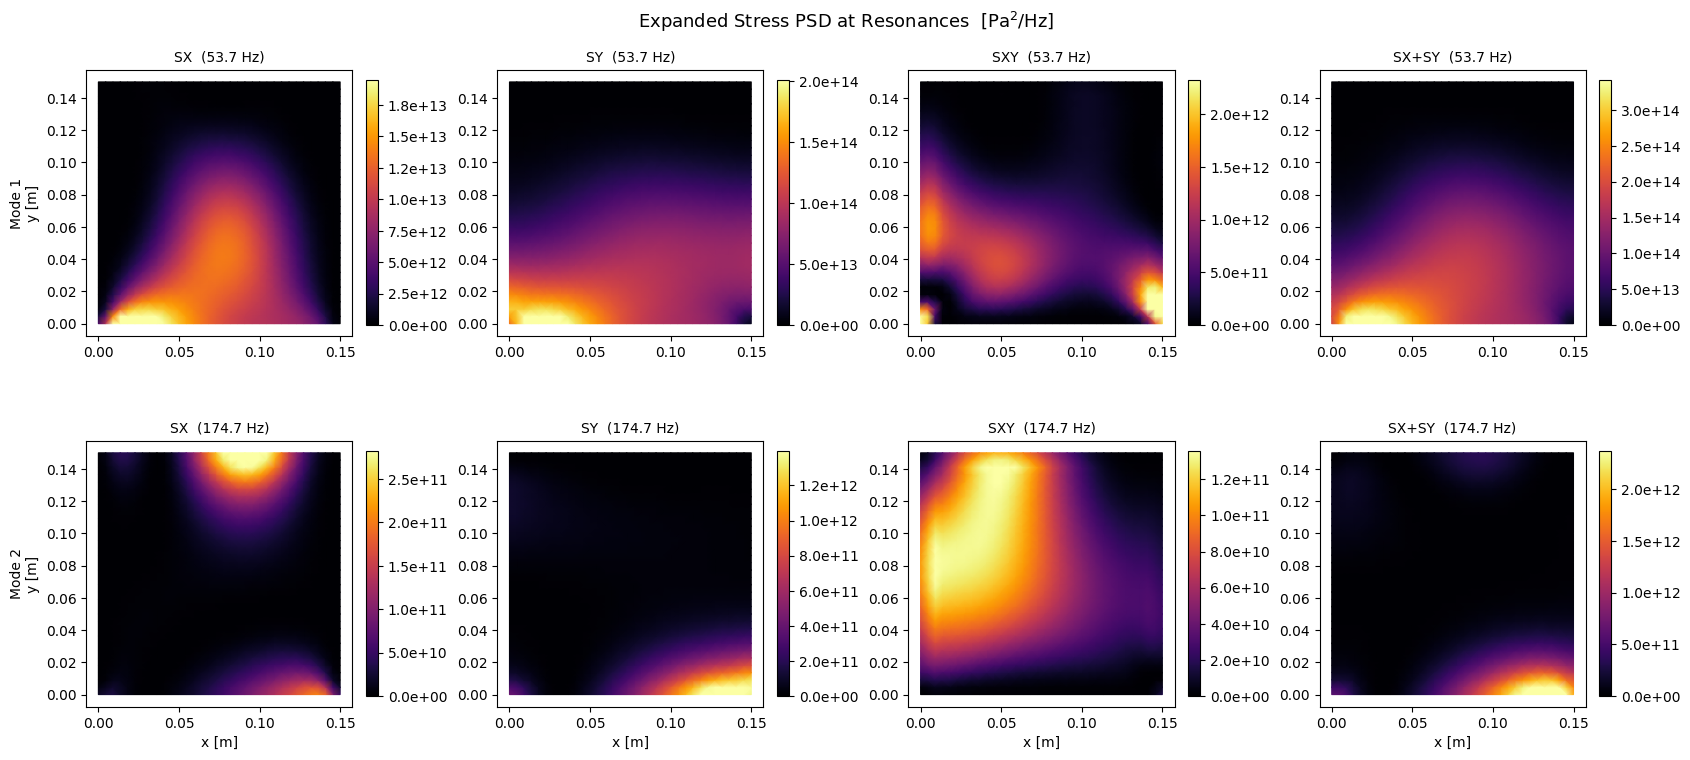

In [71]:
# ---- Stress PSD spatial maps at resonances ----
comp_list = list(COMPS.values())
n_comp = len(comp_list)

fig, axes = plt.subplots(n_modes, n_comp, figsize=(4.2 * n_comp, 3.8 * n_modes),
                         constrained_layout=True)
if n_modes == 1:
    axes = axes[None, :]

for m in range(n_modes):
    k_res = np.argmin(np.abs(freq_b - f_peaks[m]))
    for j, label in enumerate(comp_list):
        ax = axes[m, j]
        vals = S_stress[label][k_res]
        vmin, vmax = safe_clim(vals)
        tc = ax.tripcolor(tri, vals, shading='gouraud', cmap='inferno',
                          vmin=vmin, vmax=vmax)
        plt.colorbar(tc, ax=ax, fraction=0.046, pad=0.04, format='%.1e')
        ax.set_aspect('equal')
        ax.set_title(f'{label}  ({freq_b[k_res]:.1f} Hz)', fontsize=10)
        if j == 0:
            ax.set_ylabel(f'Mode {m+1}\ny [m]')
        if m == n_modes - 1:
            ax.set_xlabel('x [m]')

fig.suptitle('Expanded Stress PSD at Resonances  [Pa$^2$/Hz]', fontsize=13, y=1.01)
plt.show()

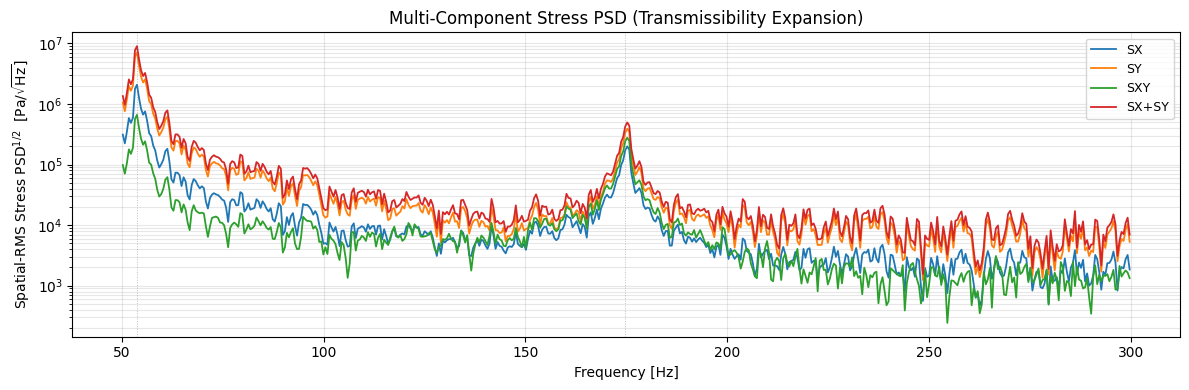

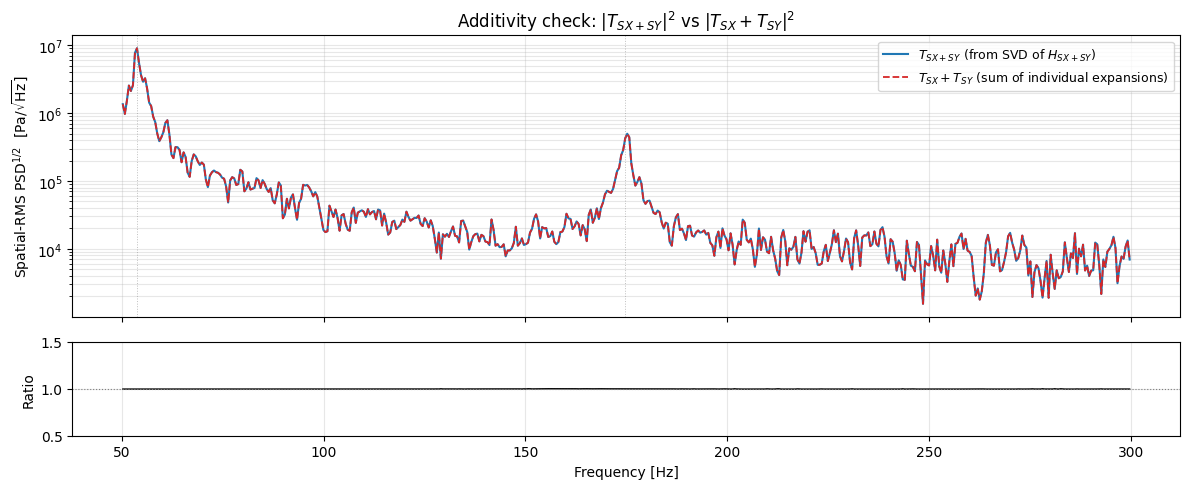

Mode shape additivity: ||psi_SX + psi_SY - psi_SX+SY|| / ||psi_SX+SY||
  Mode 1 (53.7 Hz):  relative error = 0.0030  (0.3%)
  Mode 2 (174.7 Hz):  relative error = 0.0055  (0.6%)


In [72]:
# ---- Spectral overview: spatial-RMS PSD per component ----
fig, ax = plt.subplots(figsize=(12, 4))

for label in comp_list:
    rms = np.sqrt(np.mean(S_stress[label], axis=1))   # spatial RMS
    ax.semilogy(freq_b, rms, lw=1.3, label=label)

for fp in f_peaks:
    ax.axvline(fp, color='grey', ls=':', lw=0.7, alpha=0.5)

ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Spatial-RMS Stress PSD$^{1/2}$  [Pa/$\\sqrt{\\mathrm{Hz}}$]')
ax.set_title('Multi-Component Stress PSD (Transmissibility Expansion)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

# ---- Additivity check: T_SX + T_SY vs T_SX+SY ----
# Transmissibilities (complex) should add: T_{SX+SY} ≈ T_SX + T_SY
# PSDs don't add because |A+B|² ≠ |A|² + |B|² (cross-term exists).
T_sum_check = T_expanded['SX'] + T_expanded['SY']
S_sum_check = np.abs(T_sum_check) ** 2 * S_aa_interp[:, None]

rms_sum_direct = np.sqrt(np.mean(S_sum_check, axis=1))
rms_sxsy       = np.sqrt(np.mean(S_stress['SX+SY'], axis=1))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1]})

ax1.semilogy(freq_b, rms_sxsy,       'C0',   lw=1.5, label='$T_{SX+SY}$ (from SVD of $H_{SX+SY}$)')
ax1.semilogy(freq_b, rms_sum_direct, 'C3--', lw=1.3, label='$T_{SX} + T_{SY}$ (sum of individual expansions)')
for fp in f_peaks:
    ax1.axvline(fp, color='grey', ls=':', lw=0.7, alpha=0.5)
ax1.set_ylabel('Spatial-RMS PSD$^{1/2}$  [Pa/$\\sqrt{\\mathrm{Hz}}$]')
ax1.set_title('Additivity check: $|T_{SX+SY}|^2$ vs $|T_{SX}+T_{SY}|^2$')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3, which='both')

# Ratio
ratio = rms_sum_direct / (rms_sxsy + 1e-30)
ax2.plot(freq_b, ratio, 'k', lw=1)
ax2.axhline(1.0, color='grey', ls=':', lw=0.8)
ax2.set_ylabel('Ratio')
ax2.set_xlabel('Frequency [Hz]')
ax2.set_ylim(0.5, 1.5)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ---- Mode shape additivity check ----
print('Mode shape additivity: ||psi_SX + psi_SY - psi_SX+SY|| / ||psi_SX+SY||')
for m in range(n_modes):
    psi_sum  = mode_shapes['SX'][:, m] + mode_shapes['SY'][:, m]
    psi_sxsy = mode_shapes['SX+SY'][:, m]
    rel_err  = np.linalg.norm(psi_sum - psi_sxsy) / (np.linalg.norm(psi_sxsy) + 1e-30)
    print(f'  Mode {m+1} ({f_peaks[m]:.1f} Hz):  relative error = {rel_err:.4f}  ({rel_err*100:.1f}%)')

## 7. Validation

Self-consistency check: compare direct camera Welch PSD $G_{yy}$ (includes noise), full H1 transmissibility $|T|^2 S_{aa}$ (noise-free), and modal-expanded reconstruction.

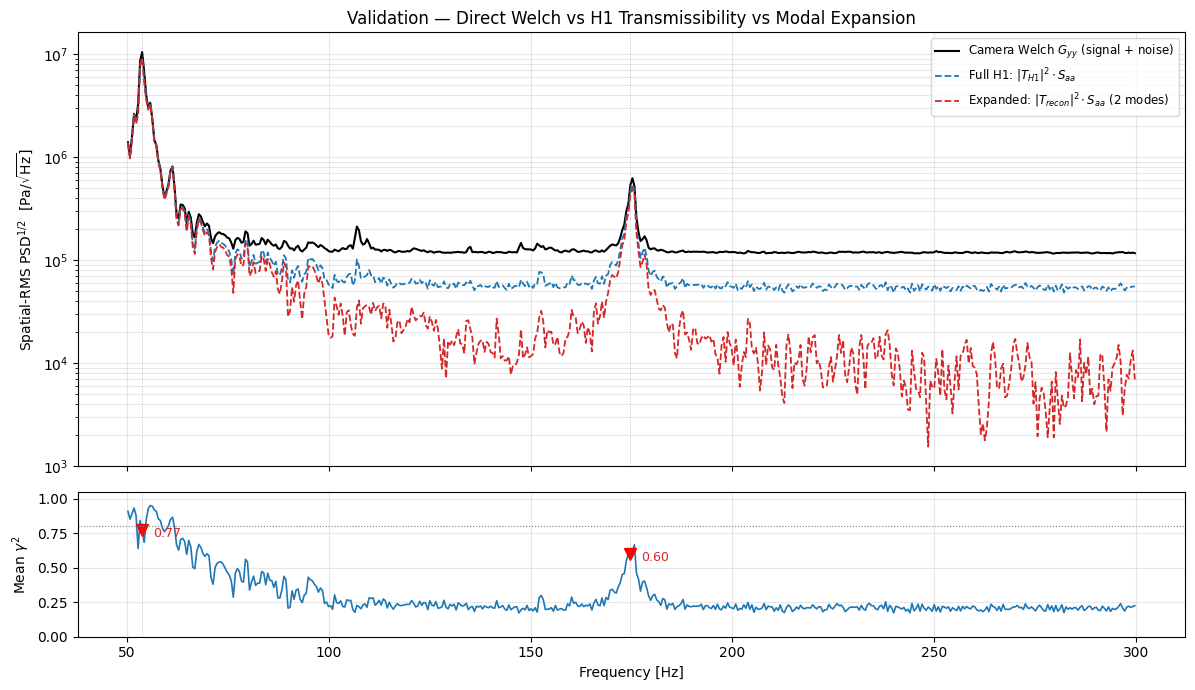

VALIDATION SUMMARY

  Mode 1 @ 53.7 Hz:
    Direct Welch  : 1.0481e+07 Pa/√Hz
    Full H1       : 9.2481e+06 Pa/√Hz
    Expanded      : 9.0280e+06 Pa/√Hz
    Coherence     : 0.775

  Mode 2 @ 174.7 Hz:
    Direct Welch  : 5.3661e+05 Pa/√Hz
    Full H1       : 4.6676e+05 Pa/√Hz
    Expanded      : 4.2563e+05 Pa/√Hz
    Coherence     : 0.600


In [73]:
# ---- Validation: Direct Welch vs H1 vs Expanded ----

# Direct camera Welch (on pixel grid)
f_cam_psd, S_cam_direct = welch(
    sigma_cam_2d, fs=FS_IR, nperseg=seg_len, window='hann', axis=0,
)
band_cam = (f_cam_psd >= F_MIN) & (f_cam_psd <= F_MAX)
S_cam_direct_b = S_cam_direct[band_cam]
f_cam_b = f_cam_psd[band_cam]

# Map direct Welch from pixels to nodes
S_cam_direct_nodes = np.zeros((S_cam_direct_b.shape[0], n_nodes))
for k in range(S_cam_direct_b.shape[0]):
    S_cam_direct_nodes[k] = camera_to_nodes(S_cam_direct_b[k], cam_to_node, n_nodes)

# Three PSD levels:
# 1. Direct camera Welch Gyy (includes noise)
rms_direct = np.sqrt(np.mean(S_cam_direct_nodes, axis=1))

# 2. Full H1 transmissibility PSD = |T|^2 * S_aa
S_h1_full = np.abs(T_cam_nodes)**2 * S_aa_interp[:, None]
rms_h1_full = np.sqrt(np.mean(S_h1_full, axis=1))

# 3. Modal-expanded PSD = |T_recon|^2 * S_aa (N_MODES_MAX-mode reconstruction)
rms_expanded = np.sqrt(np.mean(S_stress['SX+SY'], axis=1))

# ---- Plot ----
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1]})

ax1.semilogy(f_cam_b, rms_direct,     'k',    lw=1.5, label='Camera Welch $G_{yy}$ (signal + noise)')
ax1.semilogy(freq_b,  rms_h1_full,    'C0--', lw=1.3,
             label='Full H1: $|T_{H1}|^2 \\cdot S_{aa}$')
ax1.semilogy(freq_b,  rms_expanded,   'C3--', lw=1.3,
             label=f'Expanded: $|T_{{recon}}|^2 \\cdot S_{{aa}}$ ({n_modes} modes)')
for fp in f_peaks:
    ax1.axvline(fp, color='grey', ls=':', lw=0.7, alpha=0.5)
ax1.set_ylabel('Spatial-RMS PSD$^{1/2}$  [Pa/$\\sqrt{\\mathrm{Hz}}$]')
ax1.set_title('Validation — Direct Welch vs H1 Transmissibility vs Modal Expansion')
ax1.legend(fontsize=8.5, loc='upper right')
ax1.grid(True, alpha=0.3, which='both')

# Coherence subplot
coh_mean_b = np.mean(coh_nodes, axis=1)
ax2.plot(freq_b, coh_mean_b, 'C0', lw=1.2, label='$\\gamma^2$ (cam vs accel)')
for m in range(n_modes):
    k_res = np.argmin(np.abs(freq_b - f_peaks[m]))
    ax2.plot(f_peaks[m], coh_mean_b[k_res], 'rv', ms=8)
    ax2.annotate(f'{coh_mean_b[k_res]:.2f}', (f_peaks[m], coh_mean_b[k_res]),
                 textcoords='offset points', xytext=(8, -5), fontsize=9, color='C3')
ax2.axhline(0.8, color='grey', ls=':', lw=0.8)
for fp in f_peaks:
    ax2.axvline(fp, color='grey', ls=':', lw=0.7, alpha=0.5)
ax2.set_ylabel('Mean $\\gamma^2$')
ax2.set_xlabel('Frequency [Hz]')
ax2.set_ylim(0, 1.05)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ---- Quantitative summary ----
print('='*70)
print('VALIDATION SUMMARY')
print('='*70)
for m in range(n_modes):
    k_b = np.argmin(np.abs(freq_b - f_peaks[m]))
    k_d = np.argmin(np.abs(f_cam_b - f_peaks[m]))
    print(f'\n  Mode {m+1} @ {f_peaks[m]:.1f} Hz:')
    print(f'    Direct Welch  : {rms_direct[k_d]:.4e} Pa/√Hz')
    print(f'    Full H1       : {rms_h1_full[k_b]:.4e} Pa/√Hz')
    print(f'    Expanded      : {rms_expanded[k_b]:.4e} Pa/√Hz')
    print(f'    Coherence     : {coh_mean_b[k_b]:.3f}')

---
## Summary

### Outputs produced
- `T_expanded[comp]` — complex stress transmissibility for SX, SY, SXY, SX+SY at every FE node
- `S_stress[comp]` — stress PSD for all components, shape `(n_freq, n_nodes)`, units Pa$^2$/Hz
- `gamma` — modal participation functions, shape `(n_freq, n_modes)`, complex

### Method comparison (for the article)

| Property | Transmissibility expansion | Direct PSD expansion |
|----------|--------------------------|---------------------|
| **Accelerometer needed** | Yes (H1 reference) | No |
| **Noise handling** | Removed by H1 cross-spectral averaging | Removed by virtual-reference denoising |
| **Decomposes T from S_aa** | Yes — reusable structural property | No — PSD is excitation-specific |
| **What the result represents** | Noise-free structural stress PSD | Noise-free structural stress PSD |
| **Key advantage** | Predict stress under any excitation | No accelerometer required |

### Why the expanded PSD is lower than camera Welch (NOT an error)

The H1 estimator uses the cross-spectrum $G_{\sigma a}$, in which camera noise
(uncorrelated with accelerometer) cancels out. The result is:
$$|T_{H1}|^2 \cdot S_{aa} = |H|^2 \cdot S_{aa} = G_{yy} - S_{nn} = \gamma^2 \cdot G_{yy}$$

The coherence $\gamma^2$ tells us what fraction of the camera signal is structural
response (vs noise). The expansion correctly identifies and removes the noise.

The spatial mode shapes are unaffected because noise is spatially random and cancels
in the cross-spectrum. Only the overall PSD amplitude is reduced.

In [74]:
# ==============================================================================
#  SAVE ALL COMPUTED RESULTS FOR ARTICLE FIGURES
# ==============================================================================
import os

SAVE_DIR = Path(__file__).parent / 'outputs' / 'article_data' if '__file__' in dir() else Path.cwd() / 'outputs' / 'article_data'
# Robust: use notebook directory
SAVE_DIR = PROJECT_ROOT / 'dual_stage_base_pipeline' / 'outputs' / 'article_data'
os.makedirs(SAVE_DIR, exist_ok=True)

saved_files = []

# 1. Mode shapes for all 4 stress components (2 modes)
#    mode_shapes is a dict: {'SX': (n_nodes, n_modes), 'SY': ..., 'SXY': ..., 'SX+SY': ...}
for label, shapes in mode_shapes.items():
    fname = f'trans_mode_shapes_{label.replace("+", "plus")}.npy'
    np.save(SAVE_DIR / fname, shapes)
    saved_files.append(fname)

# 2. Modal parameters — natural frequencies and Stage 1 seeds
np.save(SAVE_DIR / 'trans_f_peaks.npy', f_peaks)
np.save(SAVE_DIR / 'trans_f_peaks_s1.npy', f_peaks_s1)
saved_files += ['trans_f_peaks.npy', 'trans_f_peaks_s1.npy']

# 3. Raw camera Welch PSD (before denoising) mapped to nodes
np.save(SAVE_DIR / 'trans_S_cam_direct_nodes.npy', S_cam_direct_nodes)
np.save(SAVE_DIR / 'trans_f_cam_b.npy', f_cam_b)
saved_files += ['trans_S_cam_direct_nodes.npy', 'trans_f_cam_b.npy']

# 4. H1 transmissibility T_cam_nodes (complex, freq × nodes)
np.save(SAVE_DIR / 'trans_T_cam_nodes.npy', T_cam_nodes)
saved_files.append('trans_T_cam_nodes.npy')

# 5. Coherence field (freq × nodes)
np.save(SAVE_DIR / 'trans_coh_nodes.npy', coh_nodes)
saved_files.append('trans_coh_nodes.npy')

# 6. Modal participation gamma(f) (complex, freq × n_modes)
np.save(SAVE_DIR / 'trans_gamma.npy', gamma)
saved_files.append('trans_gamma.npy')

# 7. Expanded transmissibility for each component
for label, T in T_expanded.items():
    fname = f'trans_T_expanded_{label.replace("+", "plus")}.npy'
    np.save(SAVE_DIR / fname, T)
    saved_files.append(fname)

# 8. Expanded stress PSD for each component
for label, S in S_stress.items():
    fname = f'trans_S_stress_{label.replace("+", "plus")}.npy'
    np.save(SAVE_DIR / fname, S)
    saved_files.append(fname)

# 9. Accelerometer auto-PSD S_aa(f) — both raw Welch and interpolated onto H1 grid
np.save(SAVE_DIR / 'trans_S_aa_interp.npy', S_aa_interp)
np.save(SAVE_DIR / 'trans_S_aa_welch.npy', S_aa_b)
np.save(SAVE_DIR / 'trans_f_psd_b.npy', f_psd_b)
saved_files += ['trans_S_aa_interp.npy', 'trans_S_aa_welch.npy', 'trans_f_psd_b.npy']

# 10. Frequency axes (Stage 1 and Stage 2)
np.save(SAVE_DIR / 'trans_freq_axis_s1.npy', freq_axis)
np.save(SAVE_DIR / 'trans_freq_b.npy', freq_b)
saved_files += ['trans_freq_axis_s1.npy', 'trans_freq_b.npy']

# 11. Node coordinates
np.save(SAVE_DIR / 'trans_node_coords.npy', node_coords)
saved_files.append('trans_node_coords.npy')

# 12. Reconstruction accuracy metrics and full H1 PSD
np.save(SAVE_DIR / 'trans_accuracy.npy', accuracy)
np.save(SAVE_DIR / 'trans_S_h1_full.npy', S_h1_full)
np.save(SAVE_DIR / 'trans_T_recon.npy', T_recon)
saved_files += ['trans_accuracy.npy', 'trans_S_h1_full.npy', 'trans_T_recon.npy']

# 13. Metadata (JSON)
metadata = {
    'n_nodes': int(n_nodes),
    'n_modes': int(n_modes),
    'n_freq_b': int(len(freq_b)),
    'n_freq_s1': int(n_freq_s1),
    'f_peaks_hz': f_peaks.tolist(),
    'f_peaks_s1_hz': f_peaks_s1.tolist(),
    'f_min': float(F_MIN),
    'f_max': float(F_MAX),
    'fs_ir': float(FS_IR),
    'seg_len': int(seg_len),
    'n_segments': int(N_SEGMENTS),
    'comp_labels': list(COMPS.values()),
    'rows_grid': int(rows_grid),
    'cols_grid': int(cols_grid),
    'stage1_run': STAGE1_RUN,
    'method': 'transmissibility_expansion',
}
with open(SAVE_DIR / 'trans_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
saved_files.append('trans_metadata.json')

# ---- Summary ----
print(f'Saved {len(saved_files)} files to {SAVE_DIR}')
print()
for fname in saved_files:
    fpath = SAVE_DIR / fname
    size_kb = fpath.stat().st_size / 1024
    print(f'  {fname:50s}  {size_kb:8.1f} KB')

Saved 29 files to <repo>\dual_stage_base_pipeline\outputs\article_data

  trans_mode_shapes_SX.npy                                18.2 KB
  trans_mode_shapes_SY.npy                                18.2 KB
  trans_mode_shapes_SXY.npy                               18.2 KB
  trans_mode_shapes_SXplusSY.npy                          18.2 KB
  trans_f_peaks.npy                                        0.1 KB
  trans_f_peaks_s1.npy                                     0.1 KB
  trans_S_cam_direct_nodes.npy                          4497.7 KB
  trans_f_cam_b.npy                                        4.0 KB
  trans_T_cam_nodes.npy                                 8995.2 KB
  trans_coh_nodes.npy                                   4497.7 KB
  trans_gamma.npy                                         15.7 KB
  trans_T_expanded_SX.npy                               8995.2 KB
  trans_T_expanded_SY.npy                               8995.2 KB
  trans_T_expanded_SXY.npy                              8995.2 KB
  tr